In [5]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [50]:
import mesa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from abm.model import SocialGPModel
from abm.rewards import make_mexican_hat_reward
from abm.utils import plot_reward_grid
sns.set_theme(style="whitegrid")

# Single agent simulations
This notebook shows simulations done to establish the behavior of single agents in Mexican hat environments

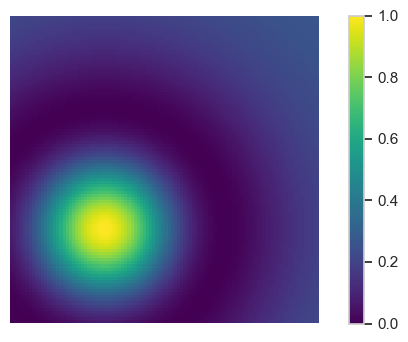

In [51]:
rng = np.random.default_rng(42)
grid_size = 100

reward = make_mexican_hat_reward(
    grid_size=grid_size,
    frequency=1.5,
    center=(30, 30)
)

plot_reward_grid(reward)

## 1. Asocial individuals, human-like parameters

In [ ]:
rng = np.random.default_rng(42)

reward_params = {
    'frequency': 1.5,
    'center': (3, 3),
    'correlation': 1
}
grid_size = 100
params = {
    "n": [100],
    "grid_size": grid_size,
    "rng": rng,
    "beta": 0.3,
    "length_scale": grid_size * 0.55 / (2*np.pi * reward_params['frequency']),
    "tau": 0.03,
    "alpha": 0,
    "reward_env_type": 'dog',
    "reward_env_params": [reward_params]
}

batch_results = mesa.batch_run(
    SocialGPModel,
    parameters=params,
    max_steps=50,
    display_progress=True,
    data_collection_period=1,
    number_processes=None,
)

  0%|          | 0/1 [00:00<?, ?it/s]